In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import math
from sklearn.preprocessing import StandardScaler
import shap

# Futher EDA
- Want to check the multicollinearity between the selected features

In [2]:
# load data with the top 50 features from previous features selection
df = pd.read_csv('df_imp.csv')
df_all = pd.read_csv('df_imp.csv')

# Define the target varibale (Total IMR)
target = 'YY_Infant_Mortality_Rate_Imr_Total_Person'

X = df.drop(target, axis=1)
y = df[target]

In [3]:
df.head()

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,QQ_Institutional_Delivery_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,...,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male,YY_Infant_Mortality_Rate_Imr_Total_Person,State_District_Name
0,Assam,5.1,53,6.7,47,76.3,8.1,6,49.6,76.7,...,5.9,76.6,7.5,8.8,6.6,47.8,78.5,8.1,43.0,Barpeta
1,Assam,4.4,89,6.3,73,79.4,8.0,16,52.0,79.0,...,5.7,67.5,6.9,9.9,6.1,46.4,66.6,7.8,48.0,Bongaigaon
2,Assam,6.3,105,7.4,84,80.3,8.3,21,61.5,80.3,...,6.9,70.6,8.0,4.1,7.3,60.2,77.1,8.2,53.0,Cachar
3,Assam,7.7,26,8.1,24,71.6,8.5,2,62.4,71.1,...,6.9,79.5,9.3,11.1,8.1,59.2,70.8,8.4,70.0,Darrang
4,Assam,3.7,121,4.5,108,77.5,5.3,13,71.6,77.0,...,4.1,79.9,4.9,9.5,4.5,67.6,78.0,5.3,37.0,Dhemaji


In [4]:
# Correlation Matrix
# Correlation between the selected features
num_feats = df.select_dtypes(include='number')
R=num_feats.corr()

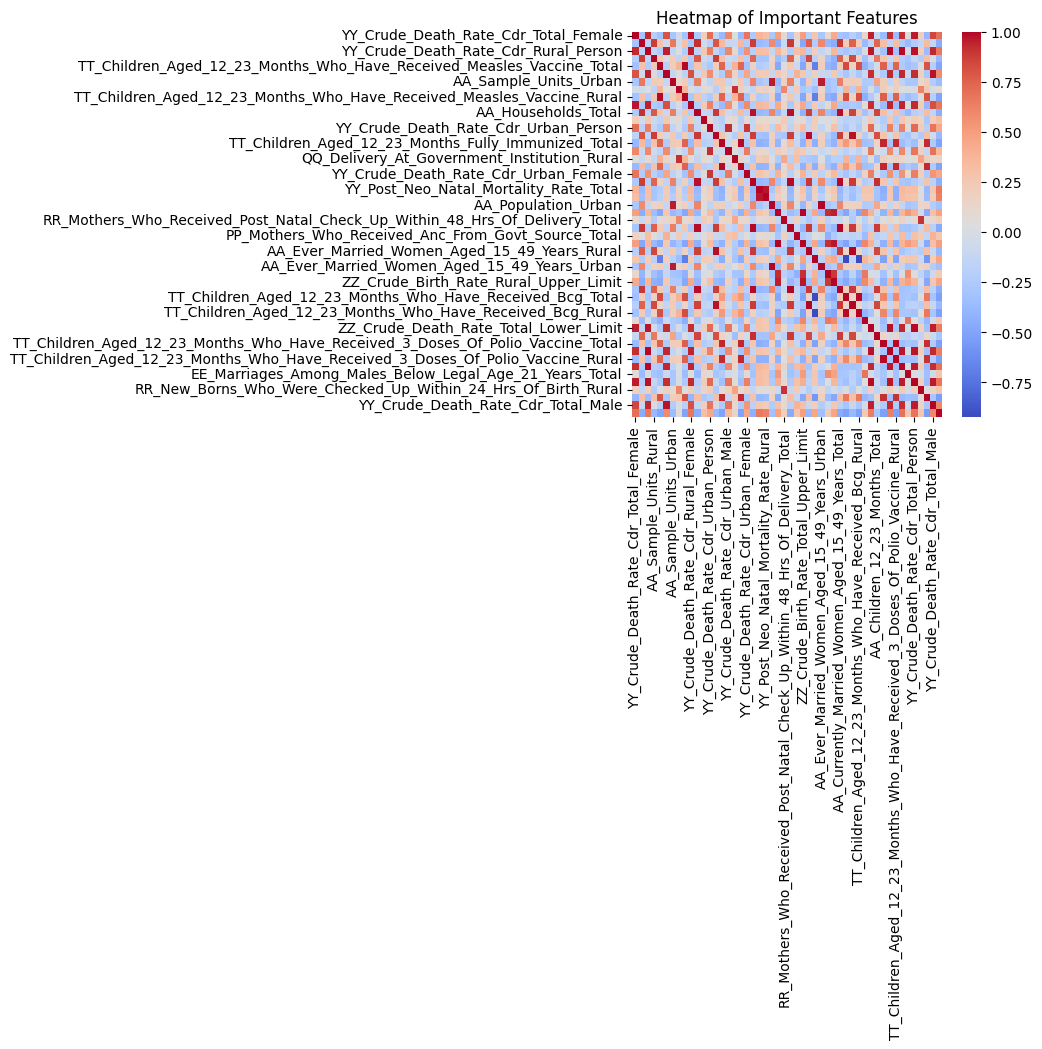

In [5]:
# Heatmap of Important Features
plt.figure(figsize=(5,5))
sns.heatmap(R,cmap='coolwarm')
plt.title("Heatmap of Important Features")
#plt.savefig('Heatmap.png')
plt.show()

# Features retained multicollinearity

# New Secondary Feature Selection
- Lasso Coefficients from before do not account for multicollinearity
- Need to develop a strategy that eliminates the impact of multicollinearity
Strategy:
- Group features together based on their correlation
  - Apply agglomerative clustering using the correlation matrix to create clusters of related features

## Group Features Based on Correlation

In [6]:
# import
from sklearn.cluster import AgglomerativeClustering

# Define the distance
# Take the absolute value of the correlation matrix
R_abs = R.abs()
dist = 1 - R_abs

# Define the clustering model
# Cluster the features
threshold = 0.5
clus = AgglomerativeClustering(
    metric = 'precomputed',
    linkage = 'complete',
    distance_threshold = 1 - threshold,
    n_clusters = None)
clus.fit(dist)

AgglomerativeClustering(distance_threshold=0.5, linkage='complete',
                        metric='precomputed', n_clusters=None)

In [7]:
# Group like-features together
groups = {}
for feat, label in zip(R.columns, clus.labels_):
    groups.setdefault(label, []).append(feat)
clus_feats = list(groups.values())

In [8]:
# grouped features
clus_feats[7].remove(target) # Remove the target variable
clus_feats

# Clusters mostly contain features with the same prefix
# This justifies the conclusion that most multicollineariry should exist within labeled groups (AA, BB, etc.)

[['YY_Crude_Death_Rate_Cdr_Total_Female',
  'YY_Crude_Death_Rate_Cdr_Rural_Person',
  'YY_Crude_Death_Rate_Cdr_Rural_Male',
  'YY_Crude_Death_Rate_Cdr_Rural_Female',
  'ZZ_Crude_Death_Rate_Total_Lower_Limit',
  'ZZ_Crude_Death_Rate_Rural_Lower_Limit',
  'ZZ_Crude_Death_Rate_Rural_Upper_Limit',
  'YY_Crude_Death_Rate_Cdr_Total_Person',
  'YY_Crude_Death_Rate_Cdr_Total_Male'],
 ['AA_Sample_Units_Total',
  'AA_Sample_Units_Rural',
  'AA_Households_Total',
  'AA_Households_Rural',
  'AA_Population_Total',
  'AA_Ever_Married_Women_Aged_15_49_Years_Total',
  'AA_Ever_Married_Women_Aged_15_49_Years_Rural',
  'AA_Currently_Married_Women_Aged_15_49_Years_Total',
  'AA_Currently_Married_Women_Aged_15_49_Years_Rural',
  'AA_Children_12_23_Months_Total'],
 ['TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total',
  'TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural',
  'TT_Children_Aged_12_23_Months_Fully_Immunized_Total',
  'TT_Children_Aged_12_23_Months_Fully_

## Group Correlations with Target
- Find the correlation between each feature and the target variable
- We can then determine the strongest predictor in each cluster

In [9]:
# Add target variable to each group to get correlations
clus_with_target = list(groups.values())
for group in clus_with_target:
    group.append(target)

In [10]:
# Correlations for each feature with the target
for group in clus_with_target:
    r = df[group].corr()
    print(r[target],'\n')

YY_Crude_Death_Rate_Cdr_Total_Female         0.694137
YY_Crude_Death_Rate_Cdr_Rural_Person         0.664542
YY_Crude_Death_Rate_Cdr_Rural_Male           0.592342
YY_Crude_Death_Rate_Cdr_Rural_Female         0.670961
ZZ_Crude_Death_Rate_Total_Lower_Limit        0.640690
ZZ_Crude_Death_Rate_Rural_Lower_Limit        0.633995
ZZ_Crude_Death_Rate_Rural_Upper_Limit        0.689815
YY_Crude_Death_Rate_Cdr_Total_Person         0.680330
YY_Crude_Death_Rate_Cdr_Total_Male           0.606216
YY_Infant_Mortality_Rate_Imr_Total_Person    1.000000
Name: YY_Infant_Mortality_Rate_Imr_Total_Person, dtype: float64 

AA_Sample_Units_Total                               -0.462644
AA_Sample_Units_Rural                               -0.379509
AA_Households_Total                                 -0.450264
AA_Households_Rural                                 -0.377386
AA_Population_Total                                 -0.434698
AA_Ever_Married_Women_Aged_15_49_Years_Total        -0.464907
AA_Ever_Married_Women_

In [11]:
# Abs correlations with target variable
corr_with_target = R[target].abs()

# Remove target variable from each group
for group in clus_feats:
    group.remove(target)
    
# Get the feature from each group with the strongest relationship with the target
selected = []
for group in clus_feats:
    best = max(group, key=lambda f: corr_with_target[f])
    selected.append(best)

In [12]:
# These are the top features from each cluster based on their correlation with the target variable
selected

['YY_Crude_Death_Rate_Cdr_Total_Female',
 'AA_Ever_Married_Women_Aged_15_49_Years_Total',
 'TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total',
 'AA_Sample_Units_Urban',
 'QQ_Delivery_At_Government_Institution_Rural',
 'VV_Children_Who_Received_Foods_Other_Than_Breast_Milk_During_First_6_Months_Vegetables_Fruits_Urban',
 'YY_Crude_Death_Rate_Cdr_Urban_Female',
 'YY_Post_Neo_Natal_Mortality_Rate_Total',
 'ZZ_Crude_Birth_Rate_Total_Upper_Limit',
 'RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural',
 'PP_Mothers_Who_Received_Anc_From_Govt_Source_Total',
 'TT_Children_Aged_12_23_Months_Who_Have_Received_Bcg_Total',
 'EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total']

# Modelling Preparation
- Outlier handling
- Data splitting
- Encoding
- Scaling

## Outlier Exceptions
- Remove outliers based on the exceptional cases identified before

In [13]:
outliers = ['Khordha', 'Dhubri', 'Balangir', 'Dehradun'] ## Outlier Cases

## Remove Outlier Cases
for district in outliers:
    df = df[df['State_District_Name'] != district]

In [14]:
# Strategy to remove outiers based on the IQR
# Ultimately made models worse

# q1 = df[target].quantile(0.25)
# q3 = df[target].quantile(0.75)
# IQR = q3-q1
# max = q3 + IQR*1.5
# min = q1 - IQR*1.5
# df = df[(df[target]<df[target].quantile(0.95))]# & (df[target]>df[target].quantile(0.05))]

<Axes: xlabel='YY_Infant_Mortality_Rate_Imr_Total_Person', ylabel='Count'>

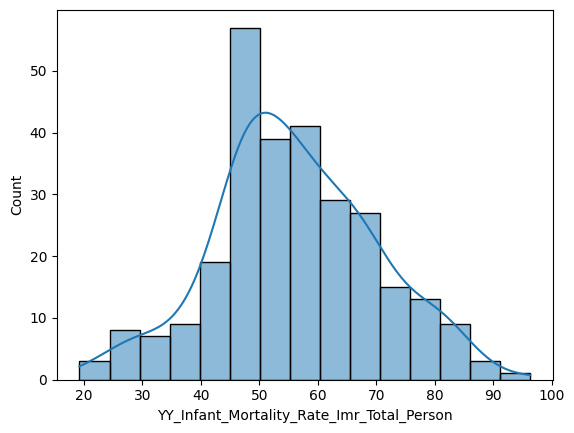

In [15]:
# Distribution of the target variable
sns.histplot(df[target], kde=True)

# Distribution is still mostly normal

## Train/Test Split

In [16]:
## Remove district name
df = df.drop('State_District_Name', axis=1)

# Split between X/y Test/Train
X = df.drop(target, axis=1)
y = df[target]
y_df = df[[target]]
X_train, X_test, y_train, y_test = train_test_split(X,y_df,test_size=0.3,random_state=42)

In [17]:
X_test.head()

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,QQ_Institutional_Delivery_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,...,AA_Children_12_23_Months_Total,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male
34,Bihar,5.20,98,5.30,87,84.00,5.50,11,73.00,85.30,...,4321,91.00,5.00,91.50,5.60,31.00,5.30,74.30,90.20,5.40
109,Madhya Pradesh,6.90,75,7.20,53,88.50,7.40,22,75.30,88.10,...,2622,70.50,6.60,68.90,7.80,7.80,6.90,74.30,72.70,7.00
243,Uttar Pradesh,7.99,41,8.37,34,66.00,8.41,7,53.35,64.68,...,2378,48.49,7.71,47.96,9.04,23.22,8.08,61.10,54.95,8.16
262,Uttar Pradesh,7.02,43,7.64,35,53.98,8.00,8,62.81,55.56,...,2038,54.95,6.92,56.64,8.35,24.76,7.41,84.33,50.96,7.80
156,Odisha,8.70,97,9.60,78,88.41,10.00,19,72.58,88.56,...,2797,92.13,9.00,91.99,10.20,7.87,9.20,72.97,86.80,9.70


## Encoding
- Target encoding the state name

In [18]:
## Import Target Encoder
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(target_type='continuous', cv=5)

# Target encode State Name
X_train[['State_Name']] = encoder.fit_transform(X_train[['State_Name']], y_train)
X_test[['State_Name']] = encoder.transform(X_test[['State_Name']])

/home/lmn4121/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Scaling
- Applying robust scaling
  - Is robust to outliers
- Standard scaler resulted in feature strengths that didn't make sense
  - Standard scaling is sensitive to outliers
  - Too many features to determine and correct skewness/outliers

In [19]:
# Apply robust scaling to features
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [20]:
X_train.head() # Scaled Features

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,QQ_Institutional_Delivery_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,...,AA_Children_12_23_Months_Total,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male
0,-0.088140,-1.157407,-0.096,-0.704225,-0.039604,-0.150070,-0.382979,0.076923,0.732092,-0.191595,...,-0.802991,-0.169114,-0.641221,-0.287380,-0.724802,1.587779,-0.803632,0.399813,-0.182379,-0.554524
1,-0.412761,0.972222,-0.320,0.892019,0.000000,-0.268876,0.553191,-0.538462,-1.227077,-0.265760,...,0.338752,0.424269,0.798255,0.454246,0.815402,0.249273,0.785471,-1.664794,0.345118,0.605568
2,0.372924,-0.092593,1.152,0.281690,0.475248,0.762858,0.212766,2.076923,0.993553,0.710754,...,0.162549,0.014835,0.231189,0.053529,0.271801,-0.752991,-0.031782,0.474719,-0.103816,0.002320
3,0.757547,1.013889,-0.640,0.971831,-0.594059,-2.237924,0.617021,-0.153846,-0.470989,-2.149567,...,0.269181,-1.840676,0.758997,-1.832237,1.055493,1.540575,0.830874,-0.538858,-1.814815,0.656613
4,-0.371866,-0.555556,0.864,-0.798122,0.950495,-0.431452,-0.936170,0.461538,-0.002149,-0.339926,...,1.304291,0.204717,-0.597601,0.280801,-0.951302,0.624313,-0.712826,-0.522472,0.165544,-0.925754


In [21]:
X_test.head()

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,QQ_Institutional_Delivery_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,...,AA_Children_12_23_Months_Total,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male
0,-0.406711,-0.833333,1.248,-1.079812,1.702970,0.075035,-1.148936,-0.076923,0.384670,0.210136,...,1.196359,0.756564,-0.859324,0.837022,-1.223103,0.979955,-0.985244,0.100187,0.681818,-1.204176
1,0.456927,-0.046296,0.512,-0.187793,0.356436,0.356417,-0.340426,0.769231,0.467049,0.383189,...,0.091678,-0.459872,-0.161396,-0.514653,-0.226501,-0.520207,-0.258797,0.100187,-0.300224,-0.461717
2,0.770417,0.458333,-0.576,0.361502,-0.396040,-1.050492,0.089362,-0.384615,-0.319126,-1.064277,...,-0.066970,-1.765910,0.322792,-1.767045,0.335221,0.476883,0.276958,-0.517790,-1.296296,0.076566
3,0.770417,0.009259,-0.512,0.018779,-0.356436,-1.802095,-0.085106,-0.307692,0.019699,-1.627936,...,-0.288036,-1.382584,-0.021810,-1.247907,0.022650,0.576463,-0.027242,0.569757,-1.520202,-0.090487
4,-0.007519,0.787037,1.216,0.938967,1.346535,0.350789,0.765957,0.538462,0.369628,0.411619,...,0.205462,0.823617,0.885496,0.866328,0.860702,-0.515681,0.785471,0.037921,0.491021,0.791183


# Modeling Strategies
The featureset needs to be further reduced:
- 50 features is still too many
- Previous attempts were lackluster

Strategy 1:
- Use the features with the strongest relationship with the target variable from each cluster

Strategy 2:
- Apply PCA to each individual cluster of features

In [22]:
## Import Models to Use
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
import xgboost
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_validate

In [23]:
## Function to run specified model and return target metrics
def run_model(model, X_train, y_train, X_test, y_test, ret_preds=False):
    # Cross Validation
    cv_res = cross_validate(model, X_train, y_train, cv=5, scoring = 'neg_mean_squared_error')
    
    # Fit the model
    model.fit(X_train, y_train)

    # Get the predictions for train and test
    train_preds = model.predict(X_train) 
    test_preds = model.predict(X_test)

    # Train and test metrics: r2 and RMSE
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = math.sqrt(mean_squared_error(y_train, train_preds))
    test_r2 = r2_score(y_test, test_preds)
    test_rmse = math.sqrt(mean_squared_error(y_test, test_preds))

    # Adjusted r2 values
    n = X_train.shape[0]; p = X_train.shape[1]
    train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
    n = X_test.shape[0]; p = X_test.shape[1]
    test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

    # dataframe of metrics
    ret = pd.DataFrame([['Train', train_r2, train_adj_r2, train_rmse], ['Test', test_r2, test_adj_r2, test_rmse]], columns = ['Subset', 'R2', 'Adjusted R2', 'RMSE'])

    # Return metrics and predictions
    if ret_preds == True:
        return train_preds, test_preds, ret
    return ret, cv_res

## Strategy 1
- Using the best feature from each cluster as a predictor

In [24]:
# Specify Selected Features
selected.append('State_Name') # Want to include the state name
X_train_1 = X_train[selected]
X_test_1 = X_test[selected]

### Baseline Regression

In [25]:
lr = LinearRegression()
results, cv = run_model(lr, X_train_1, y_train, X_test_1, y_test)
results

# Results are far superior to previous strategies
# Metrics are mostly balanced between Train and Test

,Subset,R2,Adjusted R2,RMSE
0,Train,0.830671,0.817574,5.629638
1,Test,0.825467,0.790054,5.954542


In [26]:
lr = LinearRegression() # New baseline model
train_preds,test_preds,lr_metrics=run_model(lr, X_train_1, y_train, X_test_1, y_test, ret_preds=True) # Extract predictions from the baseline model

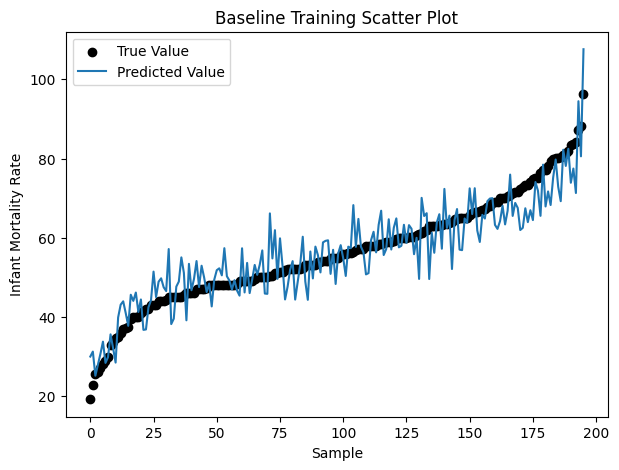

In [27]:
# Training scatter plot from the updated baseline model following strategy 1
train_residuals = y_train-train_preds # Baseline residuals
test_residuals = y_test-test_preds

train_sorted_index = y_train.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_train = pd.DataFrame(train_preds).reindex(train_sorted_index).loc[:][0]

plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(X_train_scaled)),sorted(y_train.YY_Infant_Mortality_Rate_Imr_Total_Person), color='black', label='True Value')
plt.title('Baseline Training Scatter Plot')
plt.plot(np.arange(len(X_train_scaled)),ordered_preds_train, label = 'Predicted Value')
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

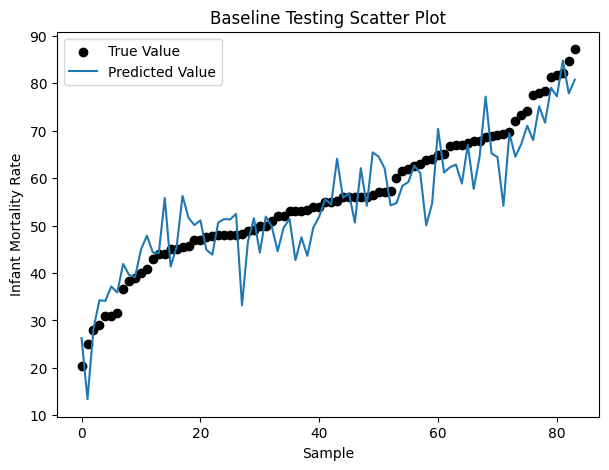

In [28]:
# Test scatter plot from the updated baseline model following strategy 1
test_sorted_index = y_test.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_test = pd.DataFrame(test_preds).reindex(test_sorted_index).loc[:][0]

plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(X_test_scaled)),sorted(y_test.YY_Infant_Mortality_Rate_Imr_Total_Person), color='black', label='True Value')
plt.title('Baseline Testing Scatter Plot')
plt.plot(np.arange(len(X_test_scaled)),ordered_preds_test, label = 'Predicted Value')
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

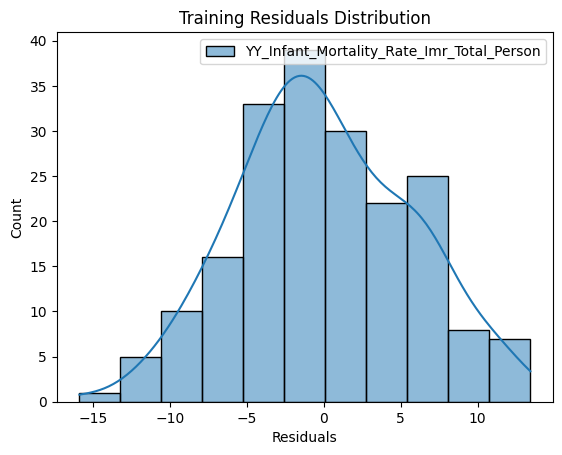

In [29]:
# Residuals Distribution (Train)
sns.histplot(train_residuals, kde=True)
plt.title('Training Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

# Residuals are normally distributed

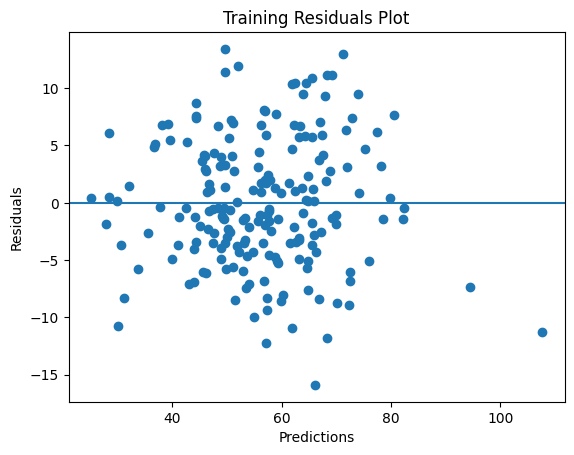

In [30]:
# Residuals plot (Train)
plt.scatter(y=train_residuals, x=train_preds)
plt.axhline(y=0)
plt.title("Training Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

# Residuals are randomly scattered around 0
# Few notable outliers

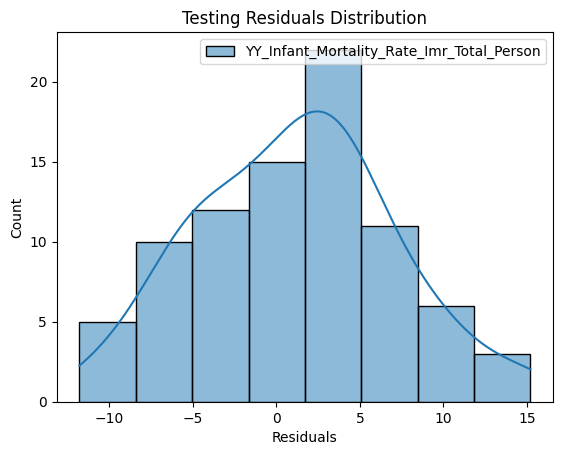

In [31]:
sns.histplot(test_residuals, kde=True)
plt.title('Testing Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

# Test residuals are normally distributed 
# Extreme outlier from before was removed

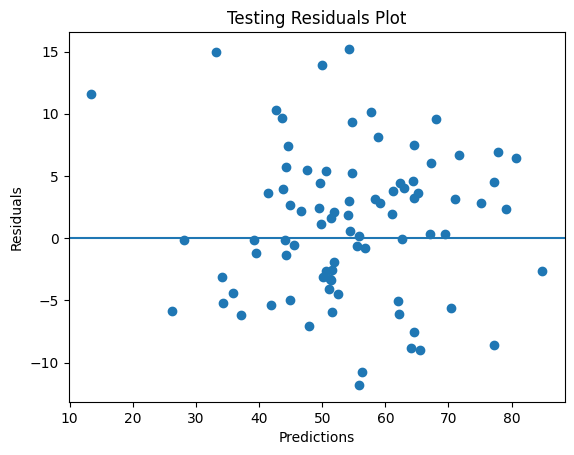

In [32]:
plt.scatter(y=test_residuals, x=test_preds)
plt.axhline(y=0)
plt.title("Testing Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

# Residuals are randomly scattered around 0
# Resiudal range is still wide

### SHAP Explainability of Baseline

In [33]:
# Shap Explainer for strategy 1
explainer_1 = shap.LinearExplainer(lr, X_train_1)
shap_values_1 = explainer_1(X_train_1)

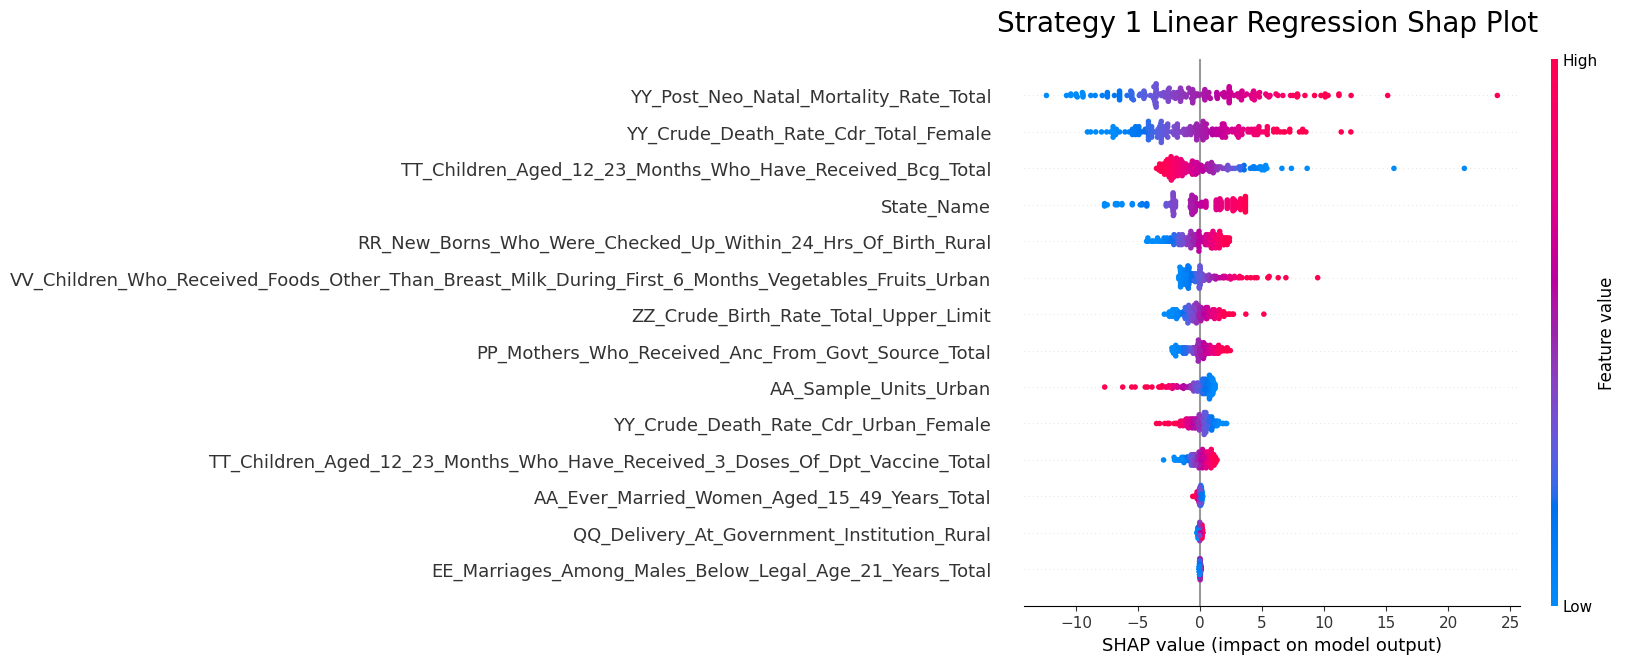

In [34]:
# Beeswarm plot for global explainability
# Inspection of general feature impacts on predictions
shap.plots.beeswarm(shap_values_1, max_display = len(shap_values_1[1]), show=False)
plt.suptitle("Strategy 1 Linear Regression Shap Plot", y=0.95, x=0.43, fontsize=20)
#plt.savefig('s1_beeswarm.png', bbox_inches='tight')
plt.show()

# Neo Natal, Death rate, and state are the strongest predictors
# Vaccination rates also have a strong impact

### Inspection of Residual Outliers

In [35]:
# Individual Cases
# Collect and store predicted values and resiudals from testing set
special_cases = y_train.copy(deep=True)
special_cases['Predicted'] = train_preds
special_cases['Residuals'] = train_residuals

In [36]:
state_dist = df_all[['State_Name', 'State_District_Name']] # Get state and district names
special_cases = pd.concat([state_dist, special_cases], axis=1, join='inner')

In [37]:
z_scaler = StandardScaler()
# Standardize the residuals
special_cases['Standard_Residuals'] = z_scaler.fit_transform(special_cases[['Residuals']])

In [38]:
# Find outler cases where abs residucals z-score > 1.9
outlier_cases = special_cases[np.abs(special_cases['Standard_Residuals'])>=1.9]
outlier_cases.rename(columns={target: 'y_true'})

# Most outliers are in Uttar Pradesh

,State_Name,State_District_Name,y_true,Predicted,Residuals,Standard_Residuals
21,Assam,Sonitpur,61.00,49.602770,11.397230,2.024505
40,Bihar,Madhepura,64.00,52.108777,11.891223,2.112254
54,Bihar,Sheikhpura,51.00,61.918211,-10.918211,-1.939416
178,Rajasthan,Chittaurgarh,63.00,49.579770,13.420230,2.383853
216,Uttar Pradesh,Budaun,84.28,71.299782,12.980218,2.305693
226,Uttar Pradesh,Firozabad,56.46,68.245270,-11.785270,-2.093433
232,Uttar Pradesh,Hamirpur,44.94,57.149440,-12.209440,-2.168779
239,Uttar Pradesh,Kannauj,79.39,68.273184,11.116816,1.974695
249,Uttar Pradesh,Mainpuri,50.27,66.155507,-15.885507,-2.821764
260,Uttar Pradesh,Saharanpur,76.40,65.537706,10.862294,1.929484


In [39]:
outliers_train = list(outlier_cases.State_District_Name)

### Modelling with Strategy 1

#### Linear Models

In [40]:
## Lasso Regularization
llr = Lasso()
results, cv_scores = run_model(llr, X_train_1, y_train, X_test_1, y_test)
results

# Worse than baseline
# This indicates that Lasso 0s out important features

,Subset,R2,Adjusted R2,RMSE
0,Train,0.794487,0.778591,6.202040
1,Test,0.797251,0.756114,6.417832


In [41]:
# Ridge Regularlization
rlr = Ridge()
results, cv_scores = run_model(rlr, X_train_1, y_train, X_test_1, y_test)
results

# Performs the same as basline

,Subset,R2,Adjusted R2,RMSE
0,Train,0.830622,0.817521,5.630452
1,Test,0.825345,0.789908,5.956613


#### Basic Decision Tree

In [42]:
# Decision Tree Regression
dc = DecisionTreeRegressor(max_depth=3)
results, cv_scores = run_model(dc, X_train_1, y_train, X_test_1, y_test)
results

# Model is still overfitting

,Subset,R2,Adjusted R2,RMSE
0,Train,0.704669,0.681826,7.434810
1,Test,0.589453,0.506154,9.132518


#### Ensemble Models

In [43]:
rf = RandomForestRegressor(max_depth=3, n_estimators=10)
results, cv_scores = run_model(rf, X_train_1, y_train.iloc[:, 0], X_test_1, y_test.iloc[:, 0])
results

# RF still overfits
# Metrics are better than before

,Subset,R2,Adjusted R2,RMSE
0,Train,0.806776,0.791831,6.013754
1,Test,0.742390,0.690122,7.234198


In [44]:
xg = xgboost.XGBRegressor(max_depth=3, alpha=0.001)
results, cv_scores = run_model(xg, X_train_1, y_train, X_test_1, y_test)
results

#XGBoost still overfits

,Subset,R2,Adjusted R2,RMSE
0,Train,0.999331,0.999279,0.353858
1,Test,0.826617,0.791438,5.934879


In [45]:
# AdaBoost
ada = AdaBoostRegressor(estimator=LinearRegression(), n_estimators=100, learning_rate=0.001, random_state=42)
results, ada_cv_scores = run_model(ada, X_train_1, y_train.iloc[:, 0], X_test_1, y_test)
results
# Best model thus far

,Subset,R2,Adjusted R2,RMSE
0,Train,0.833173,0.820270,5.587890
1,Test,0.830153,0.795691,5.874054


In [46]:
# AdaBoost CV scores
pd.DataFrame(ada_cv_scores).describe() # Based on negative MSE

,fit_time,score_time,test_score
count,5.000000,5.000000,5.000000
mean,0.047895,0.003698,-43.082708
std,0.006294,0.000459,9.565287
min,0.044397,0.003418,-58.569225
25%,0.045057,0.003437,-44.556145
50%,0.045428,0.003546,-39.824959
75%,0.045465,0.003580,-39.353105
max,0.059127,0.004509,-33.110106


#### KNN

In [47]:
knn = KNeighborsRegressor(n_neighbors=10)
results, cv_scores = run_model(knn, X_train_1, y_train, X_test_1, y_test)
results

# Model is underperforming

,Subset,R2,Adjusted R2,RMSE
0,Train,0.757529,0.738774,6.736672
1,Test,0.744026,0.692090,7.211186


## Strategy 2
- Apply PCA to each clustered group of features
  - Each cluster becomes a single principal component
- Because each components features are known, it can be given an identity

### PCA

In [48]:
from sklearn.decomposition import PCA

In [49]:
## Define PCA Transformer
pca = PCA(n_components = 1, random_state=42)

In [50]:
# Create a list of DataFrames where each is a subgroup of features from the cluster groups
train_groups = []
test_groups = []
trained_pca_models = {}

# Split the data into multiple dataframes with a different cluster of features
# That is, each dataframe is one of the subsets of features
for x in range(len(clus_feats)):
    train_groups.append(X_train[clus_feats[x]])
    test_groups.append(X_test[clus_feats[x]])

# Add the state name feature
# State name is a manual selection. It was excluded from the clustering
train_groups.append(X_train[['State_Name']])
test_groups.append(X_test[['State_Name']])

# For each dataframe (subset):
## 1. define and train a PCA model for that subset of features
## 2. compress the subset into one component
## 3. store the trained PCA model into a corresponding dictionary for later use
for x in range(len(train_groups)):
    pca = PCA(n_components=1, random_state=42)
    train_groups[x] = pd.DataFrame(pca.fit_transform(train_groups[x]))
    test_groups[x] = pd.DataFrame(pca.transform(test_groups[x]))
    trained_pca_models[f'pca_clus_{x+1}'] = pca

# Since the features in each cluster are known, the features that compose each component are known
# We can assign a label to each component based on the known features
pc_names = ['Death_Rate', 'Population_And_Marriage', 'Vaccination', 'Population_Urban', 
            'Delivery', 'Foods', 'Death_Rate_Urban', 'Neo_Natal_Mortality', 'Birth_rate', 'Check_Up',
            'Government_Assist', 'BCG_Vaccination', 'Illiteracy', 'State']

# Rename PC groups
for x in range(len(train_groups)):
    train_groups[x] = train_groups[x].rename(columns={0: pc_names[x]})
    test_groups[x] = test_groups[x].rename(columns={0: pc_names[x]})

# Merge all train groups
X_train_2 = pd.DataFrame()
X_test_2 = pd.DataFrame()

for x in range(len(train_groups)):
    X_train_2 = pd.concat([X_train_2, train_groups[x]], axis=1)
    X_test_2 = pd.concat([X_test_2, test_groups[x]], axis=1)

In [51]:
# Preview of the compressed training data
X_train_2.head()

,Death_Rate,Population_And_Marriage,Vaccination,Population_Urban,Delivery,Foods,Death_Rate_Urban,Neo_Natal_Mortality,Birth_rate,Check_Up,Government_Assist,BCG_Vaccination,Illiteracy,State
0,-2.383444,-1.580908,-0.003640,-0.729459,-1.060020,0.164888,-2.022540,-0.329849,-1.205772,-0.657237,-0.020773,0.138609,1.509267,0.161286
1,2.341939,-0.101048,-0.660023,-1.465571,1.640685,-1.049940,-0.021494,0.576890,1.334725,2.549331,-0.862660,0.456634,0.914350,0.485907
2,0.292829,0.680250,-0.848434,3.694259,-1.302792,4.577572,-0.114003,-0.596998,-0.792413,-0.967070,-0.089780,-1.240518,-1.159283,-0.299778
3,2.532611,-2.034589,4.676201,-0.878467,0.709204,0.316741,1.190244,0.333566,2.533799,0.743412,0.666884,1.996195,1.728357,-0.684401
4,-2.299230,3.487103,-0.300391,-0.354598,0.188976,-0.531852,-0.105233,0.458385,-0.323059,0.524668,-1.224947,-0.620471,0.624301,0.445012


In [52]:
# Preview of the compressed testing data
X_test_2.head()

,Death_Rate,Population_And_Marriage,Vaccination,Population_Urban,Delivery,Foods,Death_Rate_Urban,Neo_Natal_Mortality,Birth_rate,Check_Up,Government_Assist,BCG_Vaccination,Illiteracy,State
0,-3.136621,3.950680,-1.737407,-0.875966,-0.347136,0.254213,-0.829237,0.681627,0.003002,-0.273373,-1.107635,-1.376809,0.903394,0.479857
1,-0.729886,-0.069272,0.179208,0.869579,-0.607660,2.380162,-0.239818,0.867194,0.171759,-0.478547,-0.462418,-0.317554,-1.122998,-0.383782
2,0.843515,-1.298173,3.406124,-1.332688,0.373276,0.184539,-1.093913,1.215202,1.055423,0.916433,-0.549367,3.477704,0.690125,-0.697271
3,-0.126959,-1.598082,3.380858,-1.077538,0.183870,1.118885,-0.274916,0.661072,0.252334,-0.765906,0.681375,5.706188,0.434272,-0.697271
4,2.450792,1.024386,-1.824004,0.467384,-0.641297,-0.639043,1.105375,-1.550800,-1.753336,-0.054816,1.149934,-1.366755,-1.177862,0.080664


### Baseline Regression Following Strategy 2

In [53]:
lr = LinearRegression() # New baseline model
train_preds_2,test_preds_2,lr_metrics=run_model(lr, X_train_2, y_train, X_test_2, y_test, ret_preds=True)
lr_metrics

# Baseline metrics are better than strategy 1

,Subset,R2,Adjusted R2,RMSE
0,Train,0.828114,0.814819,5.671986
1,Test,0.830708,0.796359,5.864450


### Baseline Residuals

In [54]:
train_residuals_2 = y_train-train_preds_2 # Baseline residuals
test_residuals_2 = y_test-test_preds_2

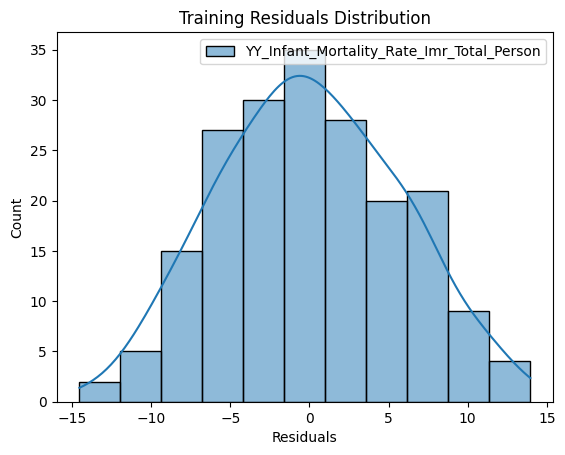

In [55]:
# Residuals Distribution
sns.histplot(train_residuals_2, kde=True)
plt.title('Training Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

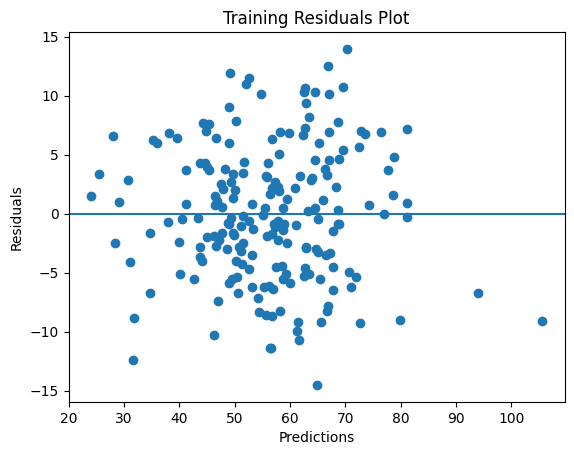

In [56]:
# Residuals plot
plt.scatter(y=train_residuals_2, x=train_preds_2)
plt.axhline(y=0)
plt.title("Training Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

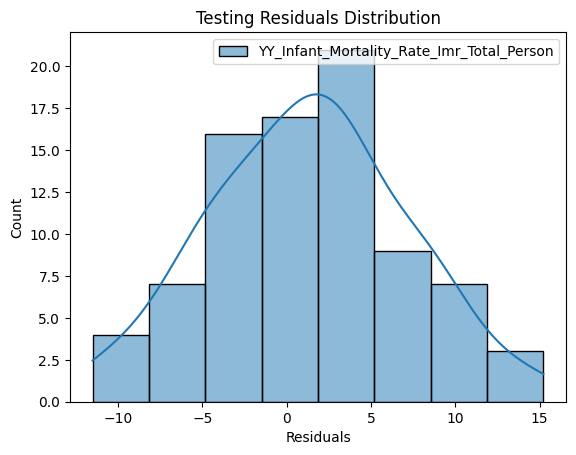

In [57]:
# Residuals Distribution
sns.histplot(test_residuals_2, kde=True)
plt.title('Testing Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

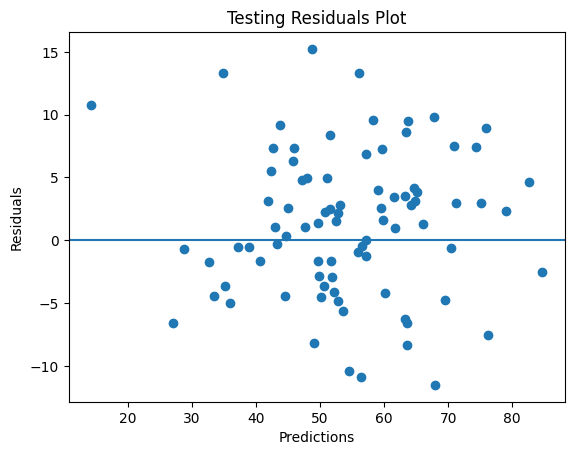

In [58]:
plt.scatter(y=test_residuals_2, x=test_preds_2)
plt.axhline(y=0)
plt.title("Testing Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

### Baseline SHAP Explainability

In [59]:
explainer_2 = shap.LinearExplainer(lr, X_train_2)
shap_values_2 = explainer_2(X_train_2)

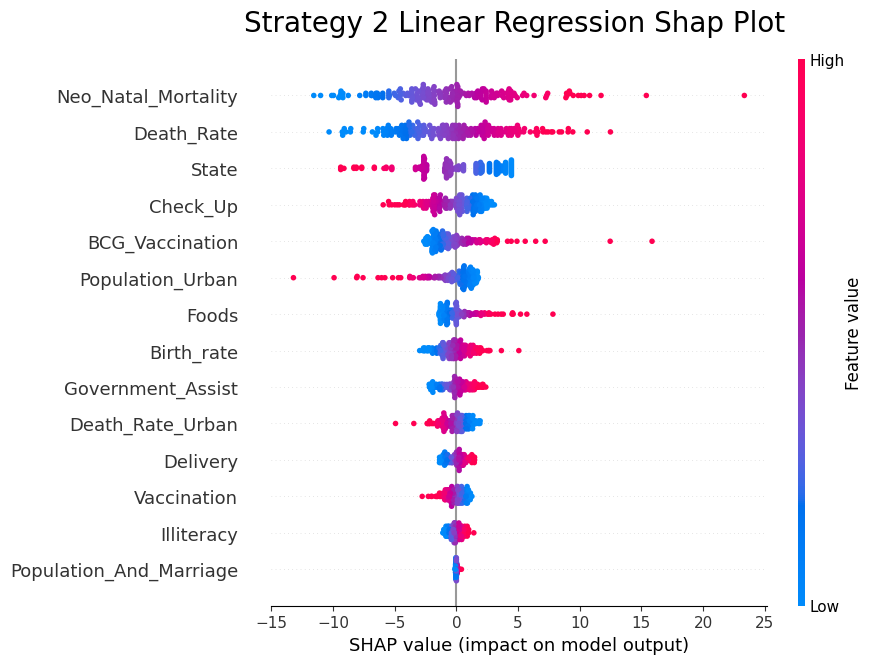

In [60]:
shap.plots.beeswarm(shap_values_2, max_display = len(shap_values_2[1]), show=False)
plt.suptitle("Strategy 2 Linear Regression Shap Plot", y=0.95, x=0.43, fontsize=20)
#plt.savefig('s2_beeswarm.png', bbox_inches='tight')
plt.show()

### Modelling Following Strategy 2

#### Linear Models

In [61]:
## Lasso
results, cv_scores = run_model(llr, X_train_2, y_train, X_test_2, y_test)
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.793894,0.777952,6.210988
1,Test,0.821942,0.785814,6.014364


In [62]:
## Ridge
results, cv_scores = run_model(rlr, X_train_2, y_train, X_test_2, y_test)
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.828079,0.814781,5.672566
1,Test,0.831944,0.797846,5.842998


#### Decision Tree

In [63]:
results, cv_scores = run_model(dc, X_train_2, y_train, X_test_2, y_test)
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.744538,0.724779,6.914779
1,Test,0.568682,0.481169,9.360687


#### Ensemble Models

In [64]:
# Random Forest
results, cv_scores = run_model(rf, X_train_2, y_train.iloc[:,0], X_test_2, y_test.iloc[:,0])
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.799386,0.783869,6.127682
1,Test,0.692014,0.629524,7.909969


In [65]:
# XGboost
results, cv_scores = run_model(xg, X_train_2, y_train, X_test_2, y_test)
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.999574,0.999541,0.282483
1,Test,0.732970,0.678791,7.365273


In [66]:
results, ada_cv_scores = run_model(ada, X_train_2, y_train.iloc[:,0], X_test_2, y_test.iloc[:,0])
results

# Metrics are better than baseline
# Test metrics are slightly better than the equivalent model for strategy 1

,Subset,R2,Adjusted R2,RMSE
0,Train,0.830548,0.817442,5.631681
1,Test,0.835491,0.802112,5.781016


In [67]:
# CV score statistics for the AdaBoost Model
pd.DataFrame(ada_cv_scores).describe()

,fit_time,score_time,test_score
count,5.000000,5.000000,5.000000
mean,0.047738,0.003987,-41.602841
std,0.004762,0.000490,8.247113
min,0.044784,0.003606,-54.589570
25%,0.044953,0.003700,-42.376986
50%,0.046077,0.003874,-41.588062
75%,0.046744,0.003922,-36.770288
max,0.056134,0.004834,-32.689297


In [68]:
#explainer_ada = shap.KernelExplainer(ada.predict, X_train_2.head(50))
#shap_values_ada = explainer_ada(X_train_2)

#shap.plots.beeswarm(shap_values_ada, max_display = len(shap_values_ada[1]), show=False)
#plt.suptitle("Strategy 2 Linear Regression Shap Plot", y=0.95, x=0.43, fontsize=20)
#plt.savefig('s2_beeswarm.png', bbox_inches='tight')
#plt.show()

#### KNN

In [69]:
results, cv_scores = run_model(knn, X_train_2, y_train, X_test_2, y_test)
results

,Subset,R2,Adjusted R2,RMSE
0,Train,0.732431,0.711735,7.076742
1,Test,0.714657,0.656761,7.613649


# Deep Learning
Originally, deep learning was not considered because the sample size is too small, however:
- Nonlinear, tree-based models are overfitting
- Linear models are mostly balanced, but are limited in depth and complexity
- Artificial Neural Networks (ANN) are inherently linear, but have more potential for complexity
  - Nonlinearity can be incorporated via activation functions
  - By adding an activation function in select locations, we can add nonlinear complexity to the model without overfitting to the extent of tree models.
- Strategy 2 (PCA) performed better than Strategy 1 (Top features), so we use the training set following strategy 2

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchinfo

torch.manual_seed(64)

## Convert Data to Tensor

In [71]:
# Convert Pandas DF to Tensor for ANN training

# Training data
# Follows strategy 2
train_values = X_train_2.values
train_tensor = torch.tensor(train_values, dtype = torch.float)
train_true = y_train.values
train_true_tensor = torch.tensor(train_true, dtype = torch.float)

# Test data
test_values = X_test_2.values
test_tensor = torch.tensor(test_values, dtype = torch.float)
test_true = y_test.values
test_true_tensor = torch.tensor(test_true, dtype = torch.float)

In [72]:
# Train tensor shape
# Shape is the same as the train_2 dataset
train_tensor.shape

torch.Size([196, 14])

## Define and Train ANN Model

In [73]:
## Define a Sequential Model
ann = nn.Sequential(
    nn.Linear(14, 64),
    #nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    #nn.ReLU(),
    #nn.Dropout(0.2),
    nn.Linear(32, 32),
    #nn.ReLU(),
    #nn.Dropout(0.2),
    nn.Linear(32, 16),
    #nn.Dropout(0.1),
    nn.ReLU(),
    nn.Linear(16, 1)
)

# 5 linear layers:
## 1 input layer
## 3 hidden layers
## 1 output layer

# 1 dropout layer included for regularization
## Should help force the model to learn from all features

# 1 ReLU activation function added after the last hidden layer
## Adds enough nonlinearity to surpass the training plateaus hit by the linear model without overfitting to the same extent as the tree models

In [74]:
# Load checkpoint weights
#weights = torch.load('ann_update.pt', weights_only=True)
#ann.load_state_dict(weights)

## Training Loop

In [75]:
# Loss Function (MSE)
loss_function = nn.MSELoss()
loss_over_time = [] # List to collect loss over time

# Optimization Function
optimizer = optim.Adam(ann.parameters(), lr = 0.0005) # Adam optimization
#optimizer = optim.SGD(ann.parameters(), lr=0.0001) # Gradient Descent optimization

# Learning Rate Scheduler
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2000)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.2) # Step Scheduler

# Training Loop
epochs = 10000

for epoch in range(epochs):
    # Zero the Gradient
    optimizer.zero_grad()
    # Make Predicitons
    preds = ann(train_tensor)
    # Calculate the Loss
    loss = loss_function(preds, train_true_tensor)
    # Back Propogation
    loss.backward()
    # Update Weights
    optimizer.step()
    # Scheduler Step
    if epoch < 5000: # Only want to update learning rate once
        scheduler.step()
    current_lr = scheduler.get_last_lr()[0] # Retrieve the current learning rate
    # print epoch loss
    loss_over_time.append(loss.item())
    if (epoch+1)%500 == 0: # Print loss and learning rate every 500 epochs
        print(f"Epoch {epoch+1} Loss: {loss.item()}  Learning Rate: {current_lr}") 

Epoch 500 Loss: 110.2525634765625  Learning Rate: 0.0005
Epoch 1000 Loss: 65.84776306152344  Learning Rate: 0.0005
Epoch 1500 Loss: 39.42262268066406  Learning Rate: 0.0005
Epoch 2000 Loss: 53.01729965209961  Learning Rate: 0.0005
Epoch 2500 Loss: 38.722862243652344  Learning Rate: 0.0005
Epoch 3000 Loss: 37.88579559326172  Learning Rate: 0.0005
Epoch 3500 Loss: 32.080440521240234  Learning Rate: 0.0005
Epoch 4000 Loss: 32.45600509643555  Learning Rate: 0.0005
Epoch 4500 Loss: 28.38436508178711  Learning Rate: 0.0005
Epoch 5000 Loss: 29.171218872070312  Learning Rate: 0.0001
Epoch 5500 Loss: 31.168258666992188  Learning Rate: 0.0001
Epoch 6000 Loss: 28.348234176635742  Learning Rate: 0.0001
Epoch 6500 Loss: 28.280258178710938  Learning Rate: 0.0001
Epoch 7000 Loss: 28.430694580078125  Learning Rate: 0.0001
Epoch 7500 Loss: 28.096689224243164  Learning Rate: 0.0001
Epoch 8000 Loss: 27.6660213470459  Learning Rate: 0.0001
Epoch 8500 Loss: 26.55166244506836  Learning Rate: 0.0001
Epoch 90

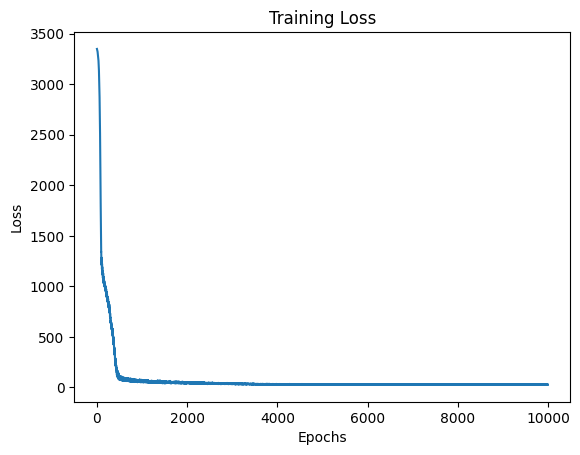

In [76]:
plt.plot(loss_over_time)
plt.title('Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.show()

## Evaluate the Model

In [77]:
# Set model to evaluation mode
ann.eval()

Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): Dropout(p=0.2, inplace=False)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)

Train R2: 0.8614918666301894
Train RMSE: 5.09158391474247
Test R2: 0.6446357423583959
Test RMSE: 8.496617710136606


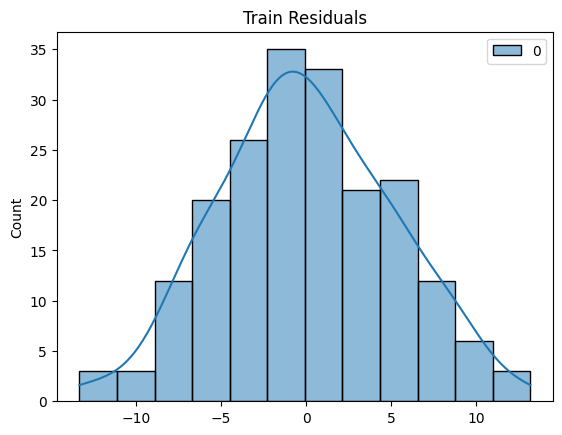

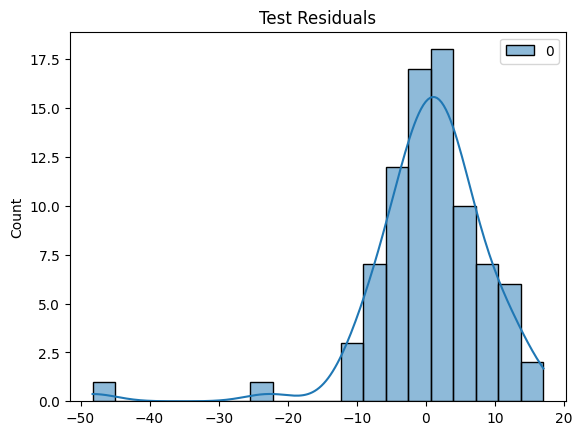

,Subset,R2,Adjusted R2,RMSE
0,Train,0.861492,0.850779,5.091584
1,Test,0.644636,0.572533,8.496618


In [78]:
# Evaluate the model
with torch.no_grad(): ## Disable Learning
    # Training Metrics
    train_preds = ann(train_tensor)
    train_r2 = r2_score(train_true_tensor, train_preds)
    train_RMSE = math.sqrt(mean_squared_error(train_true_tensor, train_preds))
    print(f"Train R2: {train_r2}")
    print(f"Train RMSE: {train_RMSE}")

    # Test Metrics
    test_preds = ann(test_tensor)
    test_r2 = r2_score(test_true_tensor, test_preds)
    test_RMSE = math.sqrt(mean_squared_error(test_true_tensor, test_preds))
    print(f"Test R2: {test_r2}")
    print(f"Test RMSE: {test_RMSE}")

    # Adjusted r2 values
    n = train_tensor.shape[0]; p = train_tensor.shape[1]
    train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
    n = test_tensor.shape[0]; p = test_tensor.shape[1]
    test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

metrics = {
    'Subset': ['Train', 'Test'],
    'R2': [train_r2, test_r2],
    'Adjusted R2': [train_adj_r2, test_adj_r2],
    'RMSE': [train_RMSE, test_RMSE]
    
}
metrics = pd.DataFrame(metrics)

# Plot the train residuals
train_residuals = train_true_tensor - train_preds
sns.histplot(train_residuals, kde=True)
plt.title("Train Residuals")
plt.show()

# Plot the test residuals
test_residuals = test_true_tensor - test_preds
sns.histplot(test_residuals, kde=True)
plt.title("Test Residuals")
plt.show()

metrics

In [79]:
# save the best model
#path = 'ann_best.pt'
#torch.save(ann.state_dict(), path)

## Best ANN Results

In [80]:
## Load Best Achieved weights
## Define the best Sequential Model architecture
ann_best = nn.Sequential(
    nn.Linear(14, 64),
    #nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    #nn.ReLU(),
    #nn.Dropout(0.2),
    nn.Linear(32, 32),
    #nn.ReLU(),
    #nn.Dropout(0.2),
    nn.Linear(32, 16),
    #nn.Dropout(0.1),
    nn.ReLU(),
    nn.Linear(16, 1)
)

best_weights = torch.load('best_ann.pt', weights_only=True)
ann_best.load_state_dict(best_weights)

<All keys matched successfully>

In [81]:
# Set to evaluation mode
ann_best.eval()

Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): Dropout(p=0.2, inplace=False)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)

In [82]:
# Creates a desciption of the model's structure and parameters
model_stats = torchinfo.summary(ann_best, input_size = [train_tensor.shape[1]])

summary = []
for layer in model_stats.summary_list:
    summary.append({
        "Layer Type": layer.class_name,
        "Input Shape": str(layer.input_size),
        "Output Shape": str(layer.output_size),
        "Param #": layer.num_params,
    })

# Create the DataFrame
summary = pd.DataFrame(summary)
summary

,Layer Type,Input Shape,Output Shape,Param #
0,Sequential,[14],[1],4641
1,Linear,[14],[64],960
2,Dropout,[64],[64],0
3,Linear,[64],[32],2080
4,Linear,[32],[32],1056
5,Linear,[32],[16],528
6,ReLU,[16],[16],0
7,Linear,[16],[1],17


In [83]:
# Model stats
model_stats

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1]                       --
├─Linear: 1-1                            [64]                      960
├─Dropout: 1-2                           [64]                      --
├─Linear: 1-3                            [32]                      2,080
├─Linear: 1-4                            [32]                      1,056
├─Linear: 1-5                            [16]                      528
├─ReLU: 1-6                              [16]                      --
├─Linear: 1-7                            [1]                       17
Total params: 4,641
Trainable params: 4,641
Non-trainable params: 0
Total mult-adds (M): 0.17
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [84]:
# Evaluate the model
with torch.no_grad(): ## Disable Learning
    # Training Metrics
    train_preds = ann_best(train_tensor)
    train_r2 = r2_score(train_true_tensor, train_preds)
    train_RMSE = math.sqrt(mean_squared_error(train_true_tensor, train_preds))

    # Test Metrics
    test_preds = ann_best(test_tensor)
    test_r2 = r2_score(test_true_tensor, test_preds)
    test_RMSE = math.sqrt(mean_squared_error(test_true_tensor, test_preds))

    # Adjusted r2 values
    n = train_tensor.shape[0]; p = train_tensor.shape[1]
    train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
    n = test_tensor.shape[0]; p = test_tensor.shape[1]
    test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

    metrics = {
        'Subset': ['Train', 'Test'],
        'R2': [train_r2, test_r2],
        'Adjusted R2': [train_adj_r2, test_adj_r2],
        'RMSE': [train_RMSE, test_RMSE]
    
    }
    metrics = pd.DataFrame(metrics)
    
metrics

# Best ANN metrics
# Far surpasses the linear and tree models from before
# Model is balanced with even train and test metrics

,Subset,R2,Adjusted R2,RMSE
0,Train,0.861235,0.850502,5.096306
1,Test,0.872335,0.846432,5.092659


In [85]:
# Save the model for deployment
#torch.save(ann_best, 'deployment_model.pth')

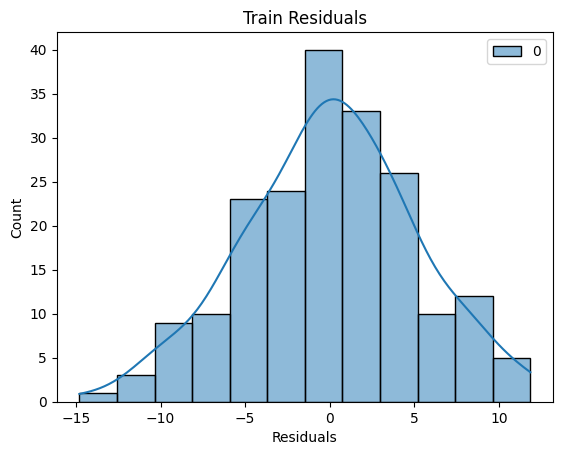

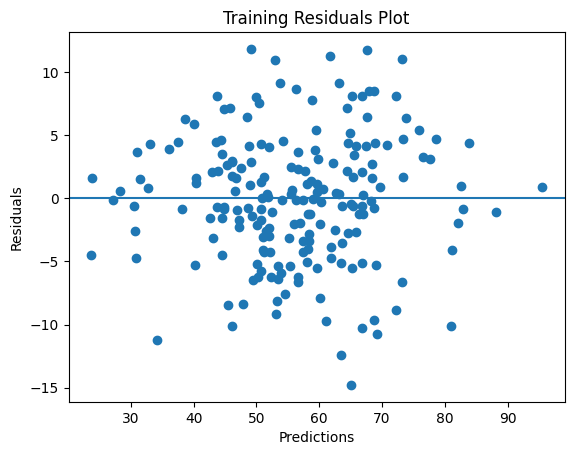

In [86]:
# Plot the train residuals
train_residuals = train_true_tensor - train_preds
sns.histplot(train_residuals, kde=True)
plt.title("Train Residuals")
plt.xlabel("Residuals")
plt.show()

plt.scatter(y=train_residuals, x=train_preds)
plt.axhline(y=0)
plt.title("Training Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

# Train residuals are normally distributed
# and randomly scattered around 0

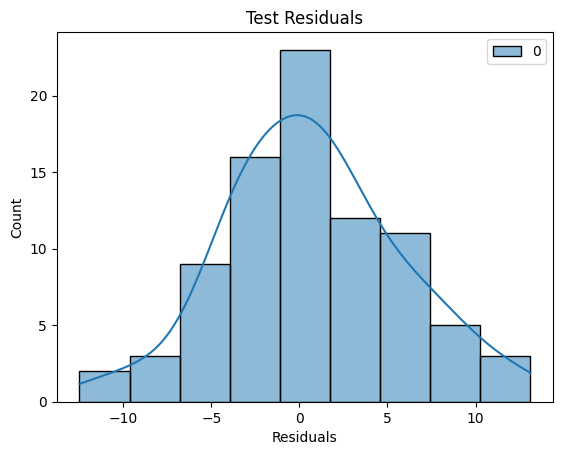

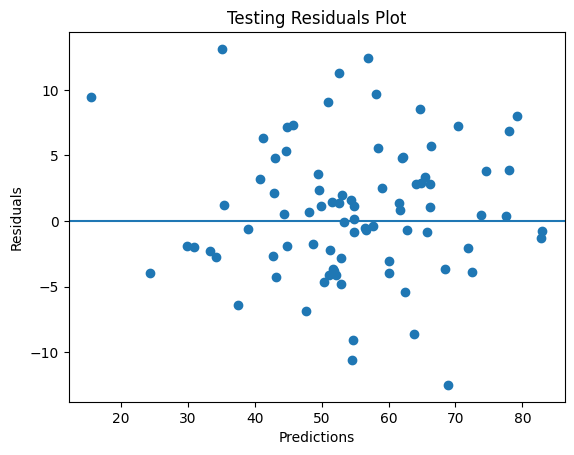

In [87]:
# Plot the test residuals
test_residuals = test_true_tensor - test_preds
sns.histplot(test_residuals, kde=True)
plt.title("Test Residuals")
plt.xlabel("Residuals")
plt.show()

plt.scatter(y=test_residuals, x=test_preds)
plt.axhline(y=0)
plt.title("Testing Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
#plt.savefig('test_.png', bbox_inches='tight')
plt.show()

# Test residuals are normally distributed
# and randomly scattered around 0
# some residuals stand out on the residuals plot

## Evaluate Predictions
- Overpredictions, Underpredictions, and Accurate Predictions
- Based on standardized residuals

In [88]:
special_cases = y_test.copy(deep=True).reset_index(drop=True)
special_cases['Predicted'] = test_preds.numpy()
special_cases['Residuals'] = test_residuals.numpy()
special_cases.rename(columns={target: 'y_true'}, inplace=True)

state_dist = df_all[['State_Name', 'State_District_Name']] # Get state and district names
special_cases = pd.concat([state_dist, special_cases], axis=1, join='inner')

z_scaler = StandardScaler()
# Standardize the residuals
special_cases['Standard_Residuals'] = z_scaler.fit_transform(special_cases[['Residuals']])

# Find outler cases where abs residucals z-score > 1.9
outlier_cases = special_cases[np.abs(special_cases['Standard_Residuals'])>=1.9]
outlier_cases

,State_Name,State_District_Name,y_true,Predicted,Residuals,Standard_Residuals
26,Bihar,Begusarai,48.14,35.025223,13.114777,2.459309
45,Bihar,Nawada,45.53,54.611057,-9.081059,-1.942578
57,Bihar,Siwan,56.45,68.942062,-12.492062,-2.619050
60,Chhattisgarh,Bastar,69.37,56.938408,12.431595,2.323820
70,Chhattisgarh,Koriya,44.03,54.594971,-10.564972,-2.236868
72,Chhattisgarh,Raigarh,63.91,52.655678,11.254322,2.090343


In [89]:
accurate_cases = special_cases[np.abs(special_cases['Standard_Residuals'])<0.3]
accurate_cases

,State_Name,State_District_Name,y_true,Predicted,Residuals,Standard_Residuals
1,Assam,Bongaigaon,62.61,61.741020,0.868980,0.030718
4,Assam,Dhemaji,53.00,51.544071,1.455929,0.147122
7,Assam,Goalpara,74.19,73.749481,0.440521,-0.054254
12,Assam,Karbi Anglong,54.93,54.757969,0.172031,-0.107501
14,Assam,Kokrajhar,55.00,52.982407,2.017593,0.258511
15,Assam,Lakhimpur,78.01,77.622803,0.387199,-0.064829
23,Bihar,Araria,36.57,35.351868,1.218132,0.099962
28,Bihar,Bhojpur,67.32,66.242332,1.077667,0.072105
29,Bihar,Buxar,53.25,53.360710,-0.110710,-0.163575
32,Bihar,Gopalganj,38.39,38.977005,-0.587006,-0.258034


## ANN Mini Model

In [90]:
# Convert Pandas DF to Tensor for ANN training

# Training data
# Follows strategy 2
train_values_mini = X_train_1.values
train_tensor_mini = torch.tensor(train_values_mini, dtype = torch.float)

# Test data
test_values_mini = X_test_1.values
test_tensor_mini = torch.tensor(test_values_mini, dtype = torch.float)

In [91]:
# Load the model
ann_mini = torch.load('ann_mini.pth', weights_only = False)

# Set to evaluation
ann_mini.eval()

Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): Dropout(p=0.2, inplace=False)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)

In [92]:
# Evaluate the model
with torch.no_grad(): ## Disable Learning
    # Training Metrics
    train_preds = ann_mini(train_tensor_mini)
    train_r2 = r2_score(train_true_tensor, train_preds)
    train_RMSE = math.sqrt(mean_squared_error(train_true_tensor, train_preds))

    # Test Metrics
    test_preds = ann_mini(test_tensor_mini)
    test_r2 = r2_score(test_true_tensor, test_preds)
    test_RMSE = math.sqrt(mean_squared_error(test_true_tensor, test_preds))

    # Adjusted r2 values
    n = train_tensor_mini.shape[0]; p = train_tensor_mini.shape[1]
    train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
    n = test_tensor.shape[0]; p = test_tensor.shape[1]
    test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

    metrics = {
        'Subset': ['Train', 'Test'],
        'R2': [train_r2, test_r2],
        'Adjusted R2': [train_adj_r2, test_adj_r2],
        'RMSE': [train_RMSE, test_RMSE]
    
    }
    metrics = pd.DataFrame(metrics)
    
metrics

# Mini ANN metrics
# Comparable to the AdaBoost Model from before
# Weaker than the full ANN model
# Only requires 14 features instead of 50
# Model is slightly overfit

,Subset,R2,Adjusted R2,RMSE
0,Train,0.838535,0.826046,5.497366
1,Test,0.837860,0.804962,5.739233


## SHAP Analysis of Best ANN

### Global Analysis

In [93]:
# Shap Analysis
explainer_ann = shap.DeepExplainer(ann_best, train_tensor)
# 1. Get raw SHAP values from your model
# shap_values_raw will likely be a numpy array of shape (n_samples, n_features)
shap_values_train = explainer_ann.shap_values(train_tensor)
shap_values_test = explainer_ann.shap_values(test_tensor)

# 2. Extract the base value
# For regression, this is usually a single scalar (the average model output)
base_val = explainer_ann.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

# 3. Handle cases where shap_values_raw is returned as a list [array]
sv_train = shap_values_train if isinstance(shap_values_train, list) else shap_values_train
sv_test = shap_values_test if isinstance(shap_values_test, list) else shap_values_test

# 4. Wrap into the Explanation object
exp_train = shap.Explanation(
    values=sv_train.squeeze(),
    base_values=base_val,
    data=train_tensor.cpu().numpy(), # Features for coloring the dots
    feature_names=X_train_2.columns      # List of strings (e.g., X.columns)
)

exp_test = shap.Explanation(
    values=sv_test.squeeze(),
    base_values=base_val,
    data=test_tensor.cpu().numpy(), # Features for coloring the dots
    feature_names=X_train_2.columns      # List of strings (e.g., X.columns)
)

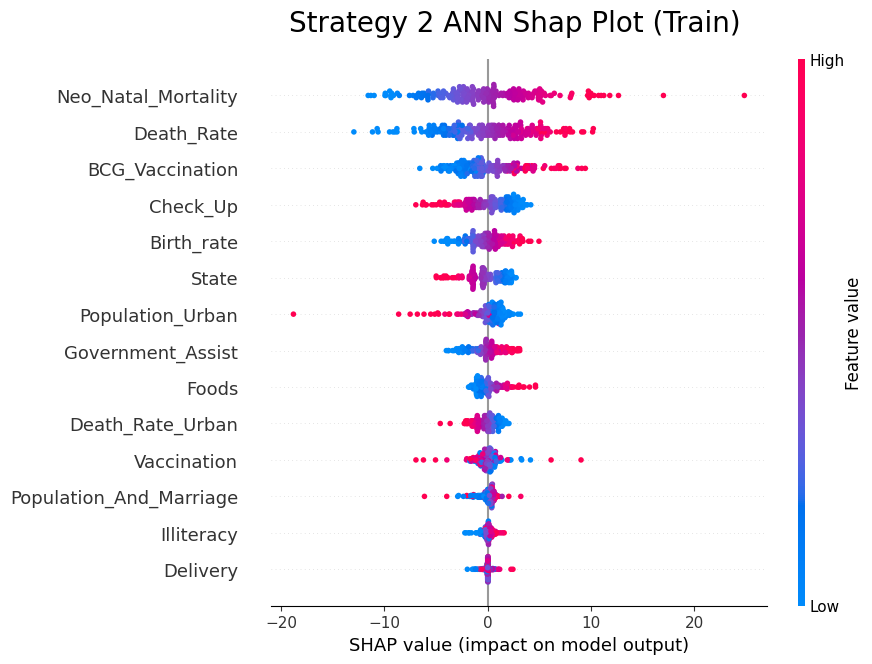

In [94]:
# Beeswarm plot for the ANN model
shap.plots.beeswarm(exp_train, max_display = len(shap_values_train[1]), show=False)
plt.suptitle("Strategy 2 ANN Shap Plot (Train)", y=0.95, x=0.43, fontsize=20)
#plt.savefig('ann_beeswarm.png', bbox_inches='tight')
plt.show()

# Neo Natal and Death rate are still the strongest predictors
# The ANN gains more value from BCG Vaccinations and check ups than state
## This differs from the previous models, which gained more value from state
# The ANN also gets more value from the weaker predictors, such as Population/Marriage, Illiteracy, and Delivery

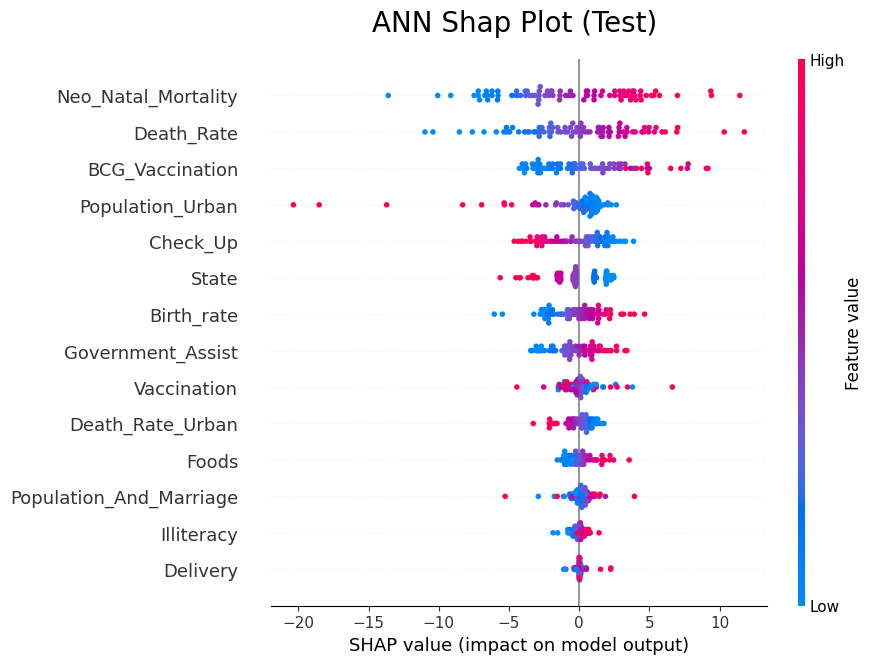

In [95]:
shap.plots.beeswarm(exp_test, max_display = len(shap_values_test[1]), show=False)
plt.suptitle("ANN Shap Plot (Test)", y=0.95, x=0.43, fontsize=20)
#plt.savefig('s1_beeswarm.png', bbox_inches='tight')
plt.show()

### Local Analysis

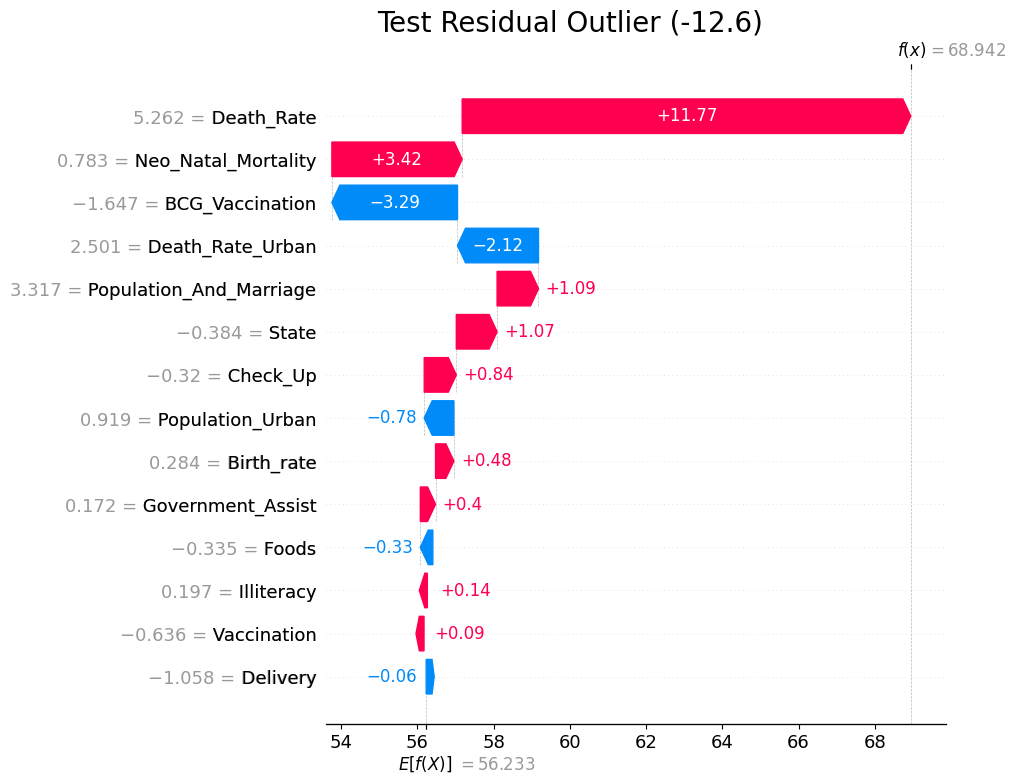

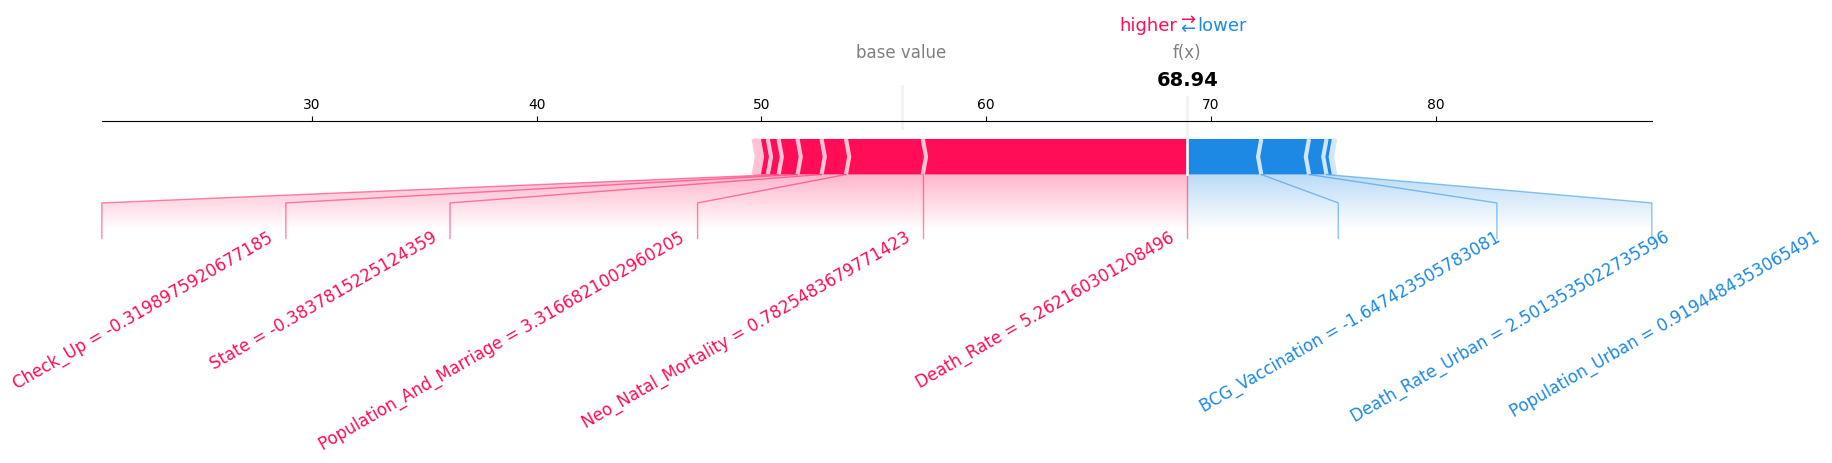

In [96]:
# Shap explanation of outlier with residual of -12.6

# Waterfall Plot
shap.plots.waterfall(exp_test[57], max_display = len(shap_values_test[0]), show=False)
plt.suptitle("Test Residual Outlier (-12.6)", y=0.95, x=0.43, fontsize=20)
#plt.savefig('neg_outlier_wf.png', bbox_inches='tight')

# Force Plot
shap.plots.force(exp_test[57], matplotlib=True, show=False, text_rotation=30)
#plt.savefig('neg_outlier_fc.png', bbox_inches='tight')
plt.show()

# Local explainability of an extreme overprediction
# The true value for this case is close to the mean, so it's not an outlier in the target variable distribution
# Death rate pushes the prediction too hight
## This likely indicates that this district is an oultier in the plot of IMR vs Death Rate
## That is, this district likely has a very high death rate but relatively low IMR

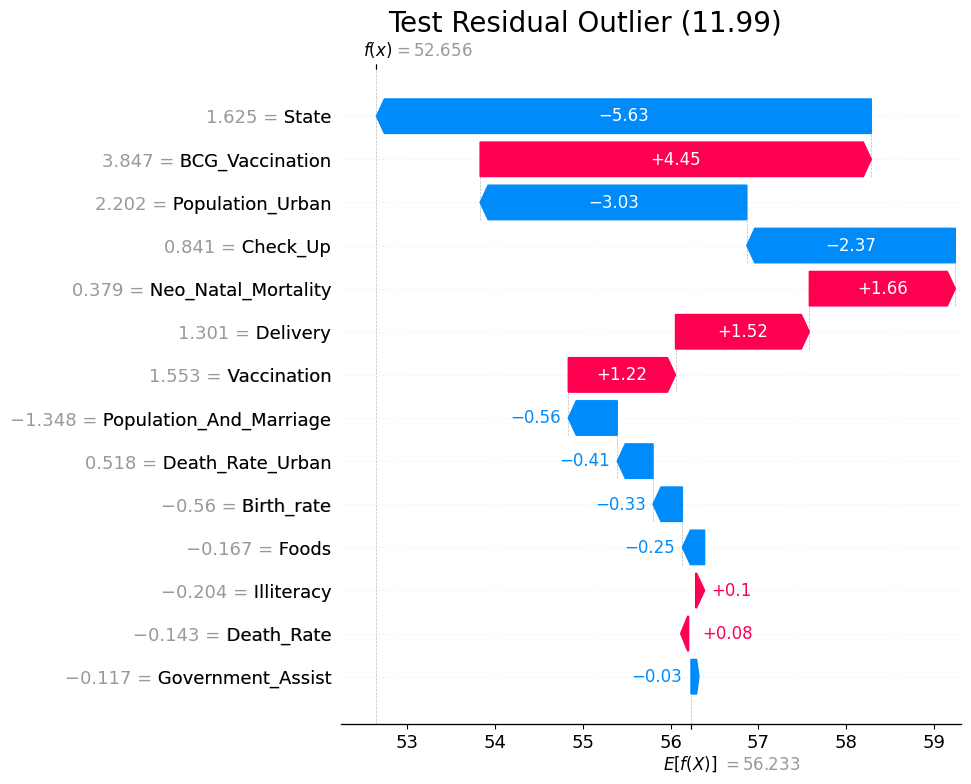

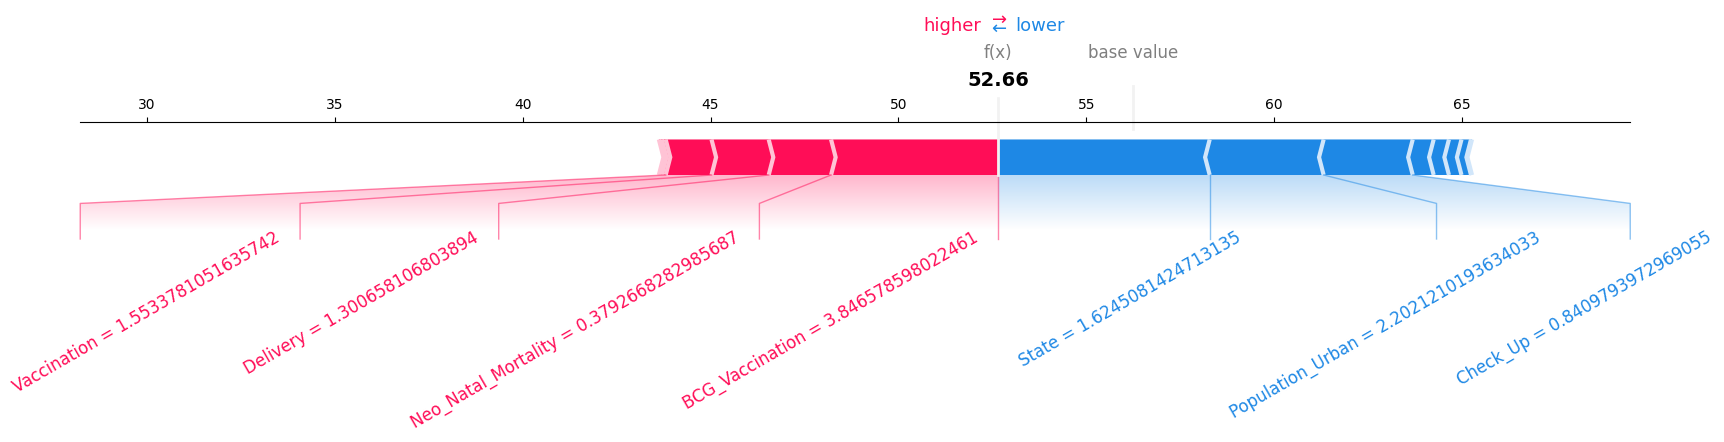

In [97]:
# Shap explanation of outlier with residual of 11.99

# Waterfall Plot
shap.plots.waterfall(exp_test[72], max_display = len(shap_values_test[0]), show=False)
plt.suptitle("Test Residual Outlier (11.99)", y=0.95, x=0.43, fontsize=20)
#plt.savefig('pos_outlier_wf.png', bbox_inches='tight')

# Force Plot
shap.plots.force(exp_test[72], matplotlib=True, show=False, text_rotation=30)
#plt.savefig('pos_outlier_fc.png', bbox_inches='tight')
plt.show()

# Local explainability of an extreme underprediction
# The state pushes the prediction too low
# This district is likely an outlier within it's state-wase distribution

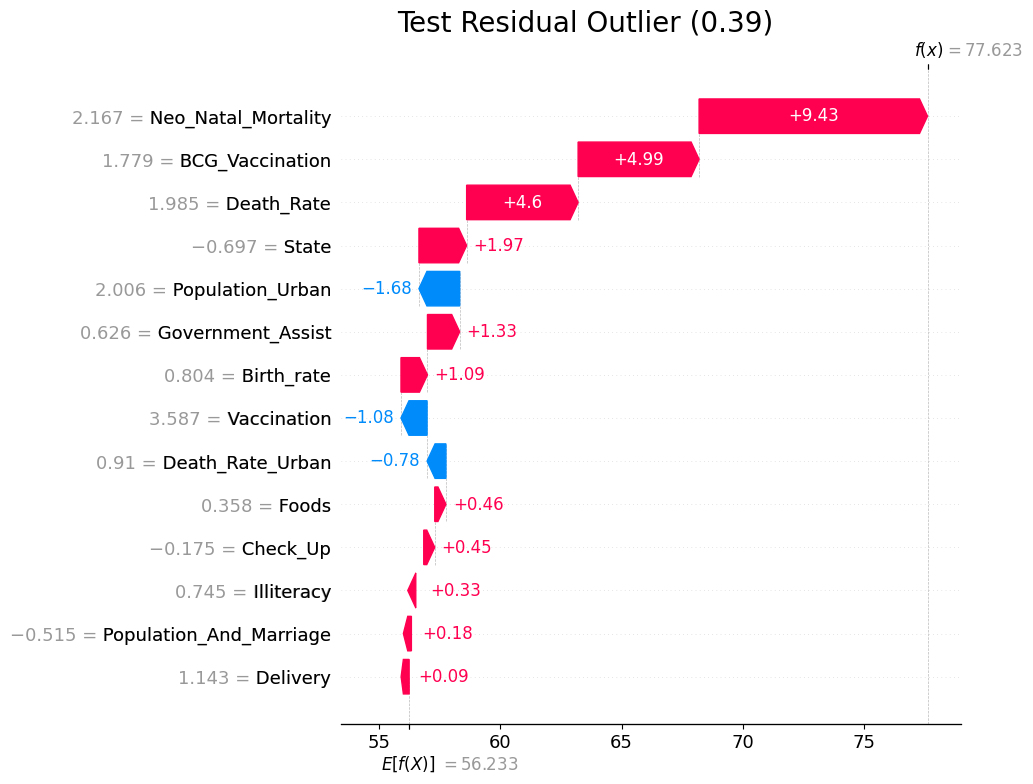

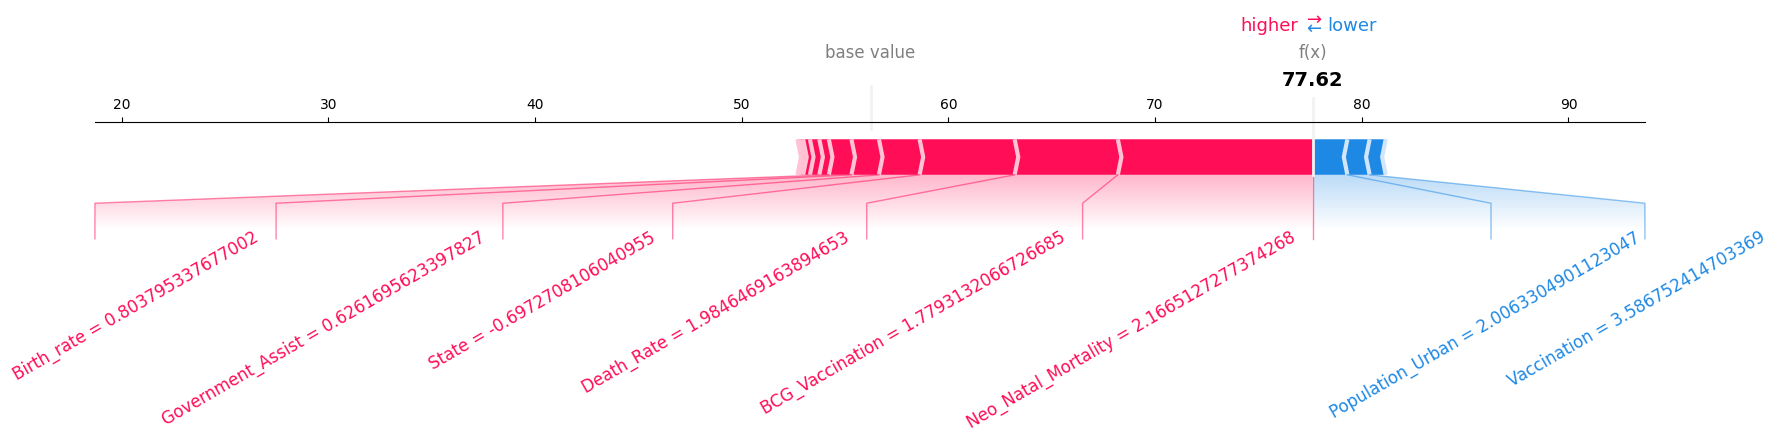

In [110]:
# Shap explanation of outlier with residual of 0.39

# Waterfall Plot
shap.plots.waterfall(exp_test[15], max_display = len(shap_values_test[0]), show=False)
plt.suptitle("Test Residual Outlier (0.39)", y=0.95, x=0.43, fontsize=20)
#plt.savefig('final_accurate_pred_wf.png', bbox_inches='tight')

# Force Plot
shap.plots.force(exp_test[15], matplotlib=True, show=False, text_rotation=30)
#plt.savefig('accurate_pred_fc.png', bbox_inches='tight')
plt.show()

# Local explaination of an accurate prediction
# Most features agree in increasing the predicion

# Exports for Deployment
#### Items to save for deployement:
- Target encoder from preprocessing
- Robust scaler
- Features in each cluster
- PCA intstances trained on each feature cluster

In [99]:
import pickle
import os

In [100]:
def save_encoder(encoder, filepath):
    """Saves the fitted encoder to a pickle file."""
    with open(filepath, 'wb') as f:
        pickle.dump(encoder, f)
    print(f"Encoder saved to {filepath}")

In [101]:
def save_scaler(scaler, filepath):
    """Saves the fitted scaler to a pickle file."""
    with open(filepath, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {filepath}")

In [102]:
def save_pca_models(pca_models_dict, folder="pca_models"):
    """Saves a dictionary of models into individual pickle files."""
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    for name, model in pca_models_dict.items():
        filepath = os.path.join(folder, f"{name}.pkl")
        with open(filepath, 'wb') as f:
            pickle.dump(model, f)
        print(f"Saved: {filepath}")

In [103]:
save_encoder(encoder, 'target_encoder.pkl')

Encoder saved to target_encoder.pkl


In [104]:
save_scaler(scaler, 'robust_scaler.pkl')

Scaler saved to robust_scaler.pkl


In [105]:
save_pca_models(trained_pca_models)

Saved: pca_models/pca_clus_1.pkl
Saved: pca_models/pca_clus_2.pkl
Saved: pca_models/pca_clus_3.pkl
Saved: pca_models/pca_clus_4.pkl
Saved: pca_models/pca_clus_5.pkl
Saved: pca_models/pca_clus_6.pkl
Saved: pca_models/pca_clus_7.pkl
Saved: pca_models/pca_clus_8.pkl
Saved: pca_models/pca_clus_9.pkl
Saved: pca_models/pca_clus_10.pkl
Saved: pca_models/pca_clus_11.pkl
Saved: pca_models/pca_clus_12.pkl
Saved: pca_models/pca_clus_13.pkl
Saved: pca_models/pca_clus_14.pkl


In [106]:
# Saving the clusters
#with open("feat_clusters.pkl", "wb") as f:
#    pickle.dump(clus_feats, f)

In [107]:
X_test.head()

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,QQ_Institutional_Delivery_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,...,AA_Children_12_23_Months_Total,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,RR_New_Borns_Who_Were_Checked_Up_Within_24_Hrs_Of_Birth_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male
0,-0.406711,-0.833333,1.248,-1.079812,1.702970,0.075035,-1.148936,-0.076923,0.384670,0.210136,...,1.196359,0.756564,-0.859324,0.837022,-1.223103,0.979955,-0.985244,0.100187,0.681818,-1.204176
1,0.456927,-0.046296,0.512,-0.187793,0.356436,0.356417,-0.340426,0.769231,0.467049,0.383189,...,0.091678,-0.459872,-0.161396,-0.514653,-0.226501,-0.520207,-0.258797,0.100187,-0.300224,-0.461717
2,0.770417,0.458333,-0.576,0.361502,-0.396040,-1.050492,0.089362,-0.384615,-0.319126,-1.064277,...,-0.066970,-1.765910,0.322792,-1.767045,0.335221,0.476883,0.276958,-0.517790,-1.296296,0.076566
3,0.770417,0.009259,-0.512,0.018779,-0.356436,-1.802095,-0.085106,-0.307692,0.019699,-1.627936,...,-0.288036,-1.382584,-0.021810,-1.247907,0.022650,0.576463,-0.027242,0.569757,-1.520202,-0.090487
4,-0.007519,0.787037,1.216,0.938967,1.346535,0.350789,0.765957,0.538462,0.369628,0.411619,...,0.205462,0.823617,0.885496,0.866328,0.860702,-0.515681,0.785471,0.037921,0.491021,0.791183


In [108]:
clus_feats

[['YY_Crude_Death_Rate_Cdr_Total_Female',
  'YY_Crude_Death_Rate_Cdr_Rural_Person',
  'YY_Crude_Death_Rate_Cdr_Rural_Male',
  'YY_Crude_Death_Rate_Cdr_Rural_Female',
  'ZZ_Crude_Death_Rate_Total_Lower_Limit',
  'ZZ_Crude_Death_Rate_Rural_Lower_Limit',
  'ZZ_Crude_Death_Rate_Rural_Upper_Limit',
  'YY_Crude_Death_Rate_Cdr_Total_Person',
  'YY_Crude_Death_Rate_Cdr_Total_Male'],
 ['AA_Sample_Units_Total',
  'AA_Sample_Units_Rural',
  'AA_Households_Total',
  'AA_Households_Rural',
  'AA_Population_Total',
  'AA_Ever_Married_Women_Aged_15_49_Years_Total',
  'AA_Ever_Married_Women_Aged_15_49_Years_Rural',
  'AA_Currently_Married_Women_Aged_15_49_Years_Total',
  'AA_Currently_Married_Women_Aged_15_49_Years_Rural',
  'AA_Children_12_23_Months_Total'],
 ['TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total',
  'TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural',
  'TT_Children_Aged_12_23_Months_Fully_Immunized_Total',
  'TT_Children_Aged_12_23_Months_Fully_